# ViEVOLVEdi

In [1]:
# Core libraries
import os
from typing import Tuple
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# Plotly configuration
import plotly.io as pio
pio.renderers.default = "jupyterlab"

In [2]:
# MetaZoo 
from metazoo.bio.evolutionary import GeneticAlgorithm
from metazoo.bio.evolutionary.operators import selection, mutation, crossover
from metazoo.bio.evolutionary.utils import Encoding, Population
# MIDI and MusicXML handling
import pretty_midi
from music21 import converter, environment
us = environment.UserSettings()
us['musicxmlPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'
us['musescoreDirectPNGPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'

In [3]:
class MelodyEncoding(Encoding):
    """
    Codifica una melodía como una secuencia de notas MIDI y duraciones rítmicas, incluyendo silencios.
    Usa 0 como nota para indicar silencio.
    """
    def __init__(self, note_range: Tuple[int, int] = (60, 72), durations: Tuple[float, ...] = (0.25, 0.5, 1.0, 2.0), length: int = 64, silence_prob: float = 0.2):
        self.note_range = note_range
        self.durations = durations
        self.length = length
        self.genome_length = length
        self.silence_prob = silence_prob

    def encode(self, population_size: int) -> np.ndarray:
        notes = np.random.randint(self.note_range[0], self.note_range[1], size=(population_size, self.length))
        # Asigna silencios aleatoriamente
        silence_mask = np.random.rand(population_size, self.length) < self.silence_prob
        notes[silence_mask] = 0
        durations = np.random.choice(self.durations, size=(population_size, self.length))
        return np.stack((notes, durations), axis=-1)

    def decode(self, individual: np.ndarray) -> np.ndarray:
        return individual

In [4]:
encoding = MelodyEncoding(note_range=(60, 72), length=16)
population = Population(population_size=100, encoding=encoding)


In [5]:
population.individuals[0]

array([[65.  ,  0.5 ],
       [69.  ,  2.  ],
       [69.  ,  2.  ],
       [68.  ,  0.5 ],
       [64.  ,  0.25],
       [68.  ,  0.5 ],
       [ 0.  ,  0.5 ],
       [ 0.  ,  2.  ],
       [60.  ,  2.  ],
       [ 0.  ,  2.  ],
       [61.  ,  0.5 ],
       [62.  ,  0.25],
       [66.  ,  2.  ],
       [63.  ,  0.25],
       [64.  ,  1.  ],
       [ 0.  ,  0.5 ]])

In [6]:
def melody_to_midi(melody, filename="melody.mid", velocity=100, instrument_name="Acoustic Grand Piano"):
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=pretty_midi.instrument_name_to_program(instrument_name))
    start = 0
    for note_number, duration in melody:
        if note_number and note_number > 0:  # Solo agrega nota si es mayor a 0
            note = pretty_midi.Note(velocity=velocity, pitch=int(note_number), start=start, end=start+duration)
            instrument.notes.append(note)
        # Avanza el tiempo aunque sea silencio
        start += duration
    pm.instruments.append(instrument)
    pm.write(filename)
    return filename

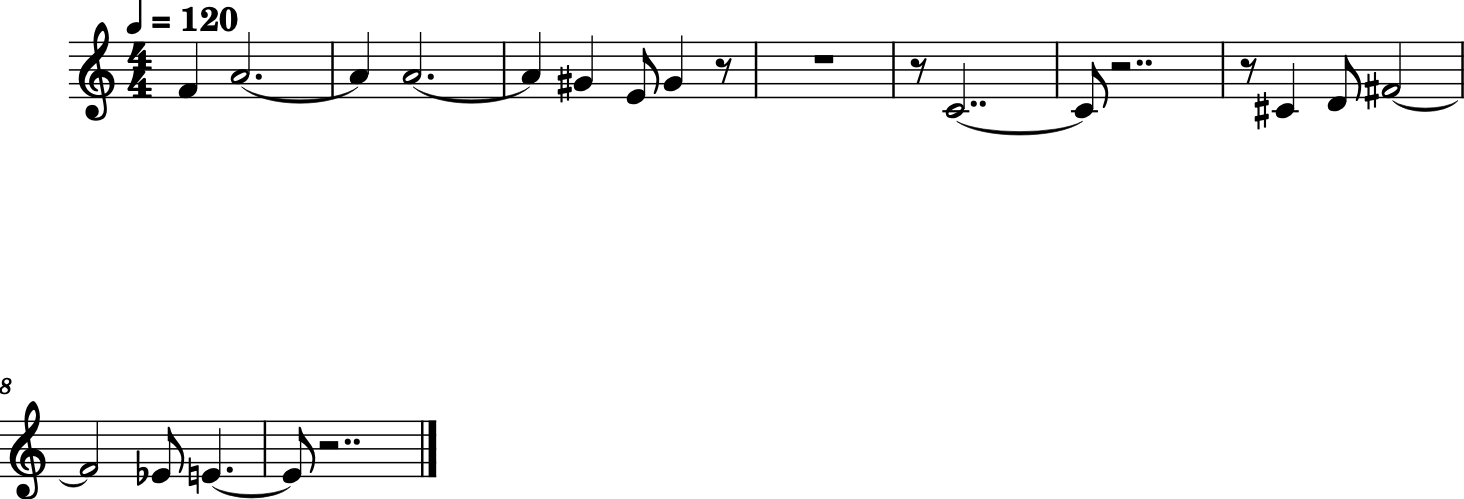

In [7]:
melody = population.individuals[0]
midi_file = melody_to_midi(melody)
score = converter.parse(midi_file)
score.show()
# delete melody.mid file
os.remove("melody.mid")

# Fitness

In [8]:
class ScoreFitness:
    def __init__(self, weights=None):
        if weights is None:
            self.weights = [
                1.0,  # diversity
                3.0,  # rhythmic_variation
                1.0,  # pitch_range
                1.0,  # temporal_density
                2.0,  # contour_variation
                1.0,  # intervallic_variety
                -0.8,  # syncopation_index
                1.0,  # tonal_stability
                3.0,  # motivic_repetition
                4.0,  # phrase_structure
                2.0,  # tension_release
                1.0,  # articulation_variation
                0.7,  # dynamic_range
                -5.0, # silent_beats (negative weight)
                2.0,  # harmonic_relation
                -2.0, # excessive_repetition (penalización)
                2.0   # melodic_resolution
            ]
        else:
            self.weights = weights

    def eval(self, melody):
        scores = [
            self.diversity(melody),
            self.rhythmic_variation(melody),
            self.pitch_range(melody),
            self.temporal_density(melody),
            self.contour_variation(melody),
            self.intervallic_variety(melody),
            self.syncopation_index(melody),
            self.tonal_stability(melody),
            self.motivic_repetition(melody),
            self.phrase_structure(melody),
            self.tension_release(melody),
            self.articulation_variation(melody),
            self.dynamic_range(melody),
            self.silent_beats(melody),
            self.harmonic_relation(melody),
            self.excessive_repetition(melody),
            self.melodic_resolution(melody)
        ]
        return scores * np.array(self.weights)

    @staticmethod
    def diversity(melody):
        """
        Returns the number of unique note-duration pairs in the melody.
        """
        return len(set(tuple(pair) for pair in melody))

    @staticmethod
    def rhythmic_variation(melody):
        durations = [float(duration) for note, duration in melody]
        return len(set(durations))

    @staticmethod
    def pitch_range(melody):
        pitches = [float(note) for note, duration in melody if note > 0]
        return max(pitches) - min(pitches) if pitches else 0

    @staticmethod
    def temporal_density(melody):
        total_duration = sum(float(duration) for note, duration in melody)
        return len(melody) / total_duration if total_duration > 0 else 0
    
    @staticmethod
    def contour_variation(melody):
        contour = []
        for i in range(1, len(melody)):
            if melody[i][0] > melody[i-1][0]:
                contour.append(1)  # Ascendente
            elif melody[i][0] < melody[i-1][0]:
                contour.append(-1)  # Descendente
            else:
                contour.append(0)  # Igual
        return len(set(contour))
    
    @staticmethod
    def intervallic_variety(melody):
        intervals = set()
        for i in range(1, len(melody)):
            if melody[i][0] > 0 and melody[i-1][0] > 0:
                interval = abs(melody[i][0] - melody[i-1][0])
                intervals.add(interval)
        return len(intervals)
    
    @staticmethod
    def syncopation_index(melody):
        syncopation = 0
        for note, duration in melody:
            if note > 0 and duration < 1.0:  # Nota en tiempo débil
                syncopation += 1
        return syncopation

    @staticmethod
    def tonal_stability(melody, key_center=60):
        stability = 0
        for note, duration in melody:
            if note > 0:
                interval = abs(note - key_center) % 12
                if interval in [0, 4, 7]:  # Notas estables en la tonalidad mayor
                    stability += 1
        return stability
    
    @staticmethod
    def motivic_repetition(melody, motif_length=4):
        motifs = {}
        for i in range(len(melody) - motif_length + 1):
            motif = tuple(map(tuple, melody[i:i+motif_length]))
            if motif in motifs:
                motifs[motif] += 1
            else:
                motifs[motif] = 1
        repetitions = sum(count - 1 for count in motifs.values() if count > 1)
        return repetitions if repetitions > 0 else -100
    
    @staticmethod
    def phrase_structure(melody, phrase_length=8):
        phrases = [tuple(map(tuple, melody[i:i+phrase_length])) for i in range(0, len(melody), phrase_length)]
        unique_phrases = set(phrases)
        return len(unique_phrases)
    
    @staticmethod
    def tension_release(melody):
        tension = 0
        for i in range(1, len(melody)):
            if melody[i][0] > melody[i-1][0]:
                tension += 1  # Ascenso genera tensión
            elif melody[i][0] < melody[i-1][0]:
                tension -= 1  # Descenso libera tensión
        return abs(tension)
    
    @staticmethod
    def articulation_variation(melody):
        articulations = set()
        for note, duration in melody:
            if note > 0:
                if duration <= 0.5:
                    articulations.add('staccato')
                else:
                    articulations.add('legato')
        return len(articulations)
    
    @staticmethod
    def dynamic_range(melody, base_velocity=100):
        velocities = []
        for note, duration in melody:
            if note > 0:
                velocities.append(base_velocity)
            else:
                velocities.append(0)
        return max(velocities) - min(velocities)

    @staticmethod
    def silent_beats(melody):
        silent_count = sum(1 for note, duration in melody if note == 0)
        return silent_count

    @staticmethod
    def harmonic_relation(melody, chords=[(60, 64, 67), (67, 71, 74), (69, 72, 76), (65, 69, 72)], phrase_length=4):
        """
        Premia notas que pertenecen al acorde correspondiente de la progresión.
        chords: lista de tuplas con notas MIDI del acorde (ejemplo: C mayor = (60, 64, 67))
        phrase_length: cuántas notas por acorde
        """
        score = 0
        for i, (note, duration) in enumerate(melody):
            if note == 0:
                continue
            chord = chords[(i // phrase_length) % len(chords)]
            if note % 12 in [n % 12 for n in chord]:
                score += 1
        return score

    @staticmethod
    def excessive_repetition(melody, max_repeats=3):
        """
        Penaliza si una nota se repite más de max_repeats veces seguidas.
        """
        penalty = 0
        count = 1
        last_note = None
        for note, duration in melody:
            if note == last_note and note != 0:
                count += 1
                if count > max_repeats:
                    penalty += 1
            else:
                count = 1
            last_note = note
        return -penalty

    @staticmethod
    def melodic_resolution(melody, tonic=60):
        """
        Premia si la última nota no silenciosa es la tónica.
        """
        for note, duration in reversed(melody):
            if note > 0:
                return 1 if note % 12 == tonic % 12 else 0
        return 0

    def fitness_function(self, melody):
        return self.eval(melody).sum()

    def plot(self, melody):
        scores = self.eval(melody)
        aspects = [
            ("Diversity", scores[0]),
            ("Rhythmic Variation", scores[1]),
            ("Pitch Range", scores[2]),
            ("Temporal Density", scores[3]),
            ("Contour Variation", scores[4]),
            ("Intervallic Variety", scores[5]),
            ("Syncopation Index", scores[6]),
            ("Tonal Stability", scores[7]),
            ("Motivic Repetition", scores[8]),
            ("Phrase Structure", scores[9]),
            ("Tension Release", scores[10]),
            ("Articulation Variation", scores[11]),
            ("Dynamic Range", scores[12]),
            ("Silent Beats", scores[13]),
            ("Harmonic Relation", scores[14]),
            ("Excessive Repetition", scores[15]),
            ("Melodic Resolution", scores[16])
        ]
        labels = [a[0] for a in aspects]
        values = [a[1] for a in aspects]
        labels += [labels[0]]
        values += [values[0]]
        fig = go.Figure(
            data=[go.Scatterpolar(r=values, theta=labels, fill='toself', name='Aspectos')]
        )
        fig.update_layout(
            polar=dict(radialaxis=dict(visible=True)),
            showlegend=False,
            title="Perfil de Fitness de la Melodía"
        )
        fig.show()

In [9]:
fitness = ScoreFitness()
fitness.plot(melody)

## Operators

In [10]:
class MelodyOperators:
    @staticmethod
    def crossover(parent1, parent2):
        # Dos puntos de corte para mayor variedad
        p1, p2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
        child1 = np.vstack((parent1[:p1], parent2[p1:p2], parent1[p2:]))
        child2 = np.vstack((parent2[:p1], parent1[p1:p2], parent2[p2:]))
        return child1, child2

    @staticmethod
    def mutation(individual, note_range=(60,72), durations=(0.25,0.5,1.0,2.0), silence_prob=0.05):
        idx = np.random.randint(len(individual))
        # Evita mutar a silencio si ya hay muchos
        if np.random.rand() < silence_prob and sum(individual[:,0]==0)/len(individual) < 0.3:
            individual[idx, 0] = 0
        else:
            individual[idx, 0] = np.random.randint(note_range[0], note_range[1])
        individual[idx, 1] = np.random.choice(durations)
        return individual

In [18]:
class MelodyGA(GeneticAlgorithm):
    def __init__(self, *args, **kwargs):
        kwargs['minimize'] = False
        super().__init__(*args, **kwargs)

## Genetic Algorithm

In [19]:
ga = MelodyGA(
    fitness_function=fitness.fitness_function,
    selection_function=selection.tournament,
    crossover_function=MelodyOperators.crossover,
    mutation_function=MelodyOperators.mutation,
    crossover_rate=0.7,
    mutation_rate=0.1,
    encoder=MelodyEncoding(note_range=(60, 72), length=128),
    elitism=0.3
)

In [20]:
ga.run(generations=1000)

Output()

In [21]:
ga.fitness_plot()

In [22]:
ga.best_individual.shape

(128, 2)

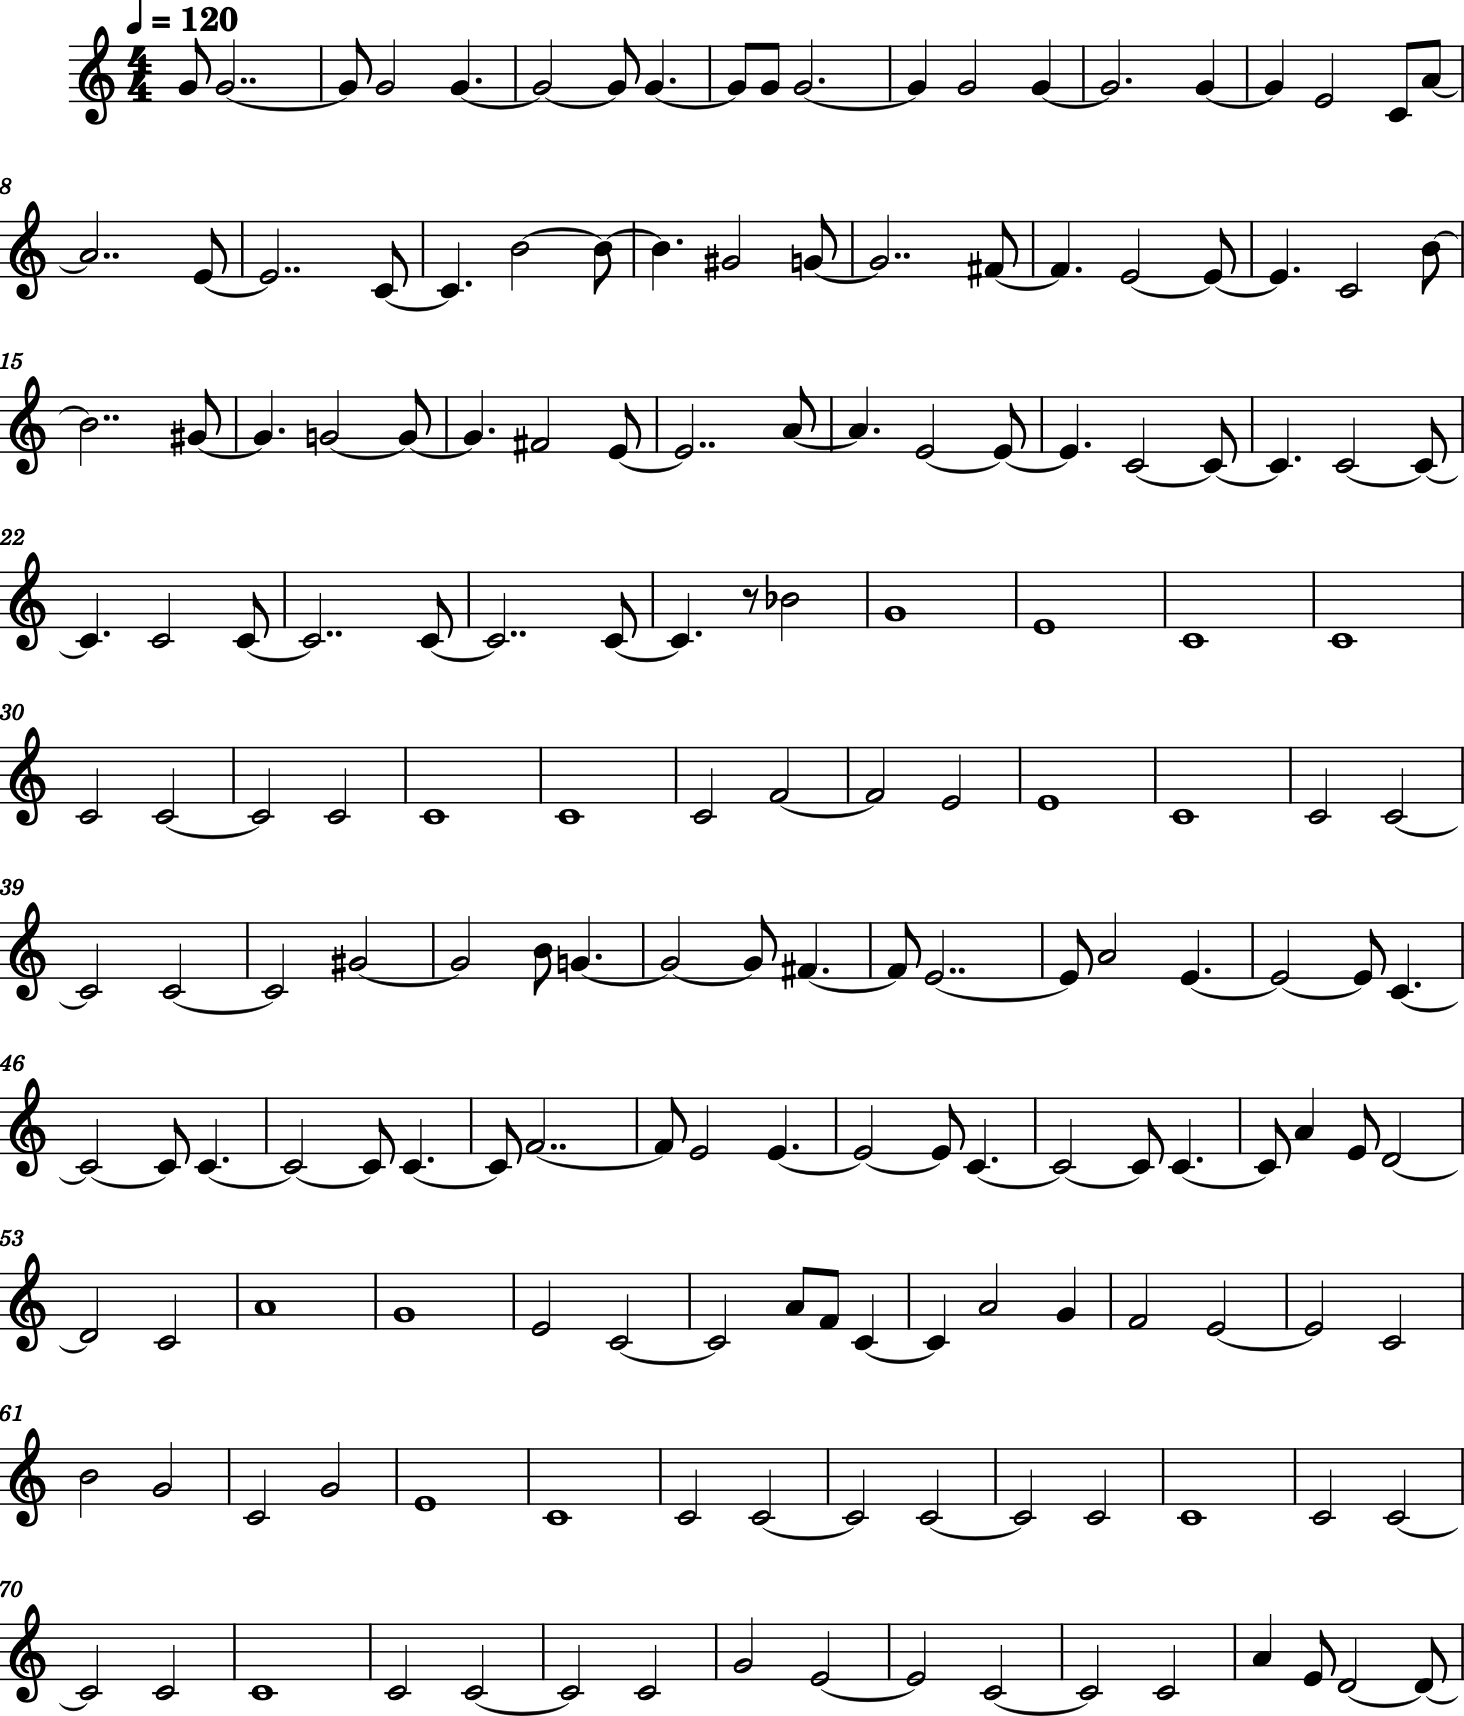

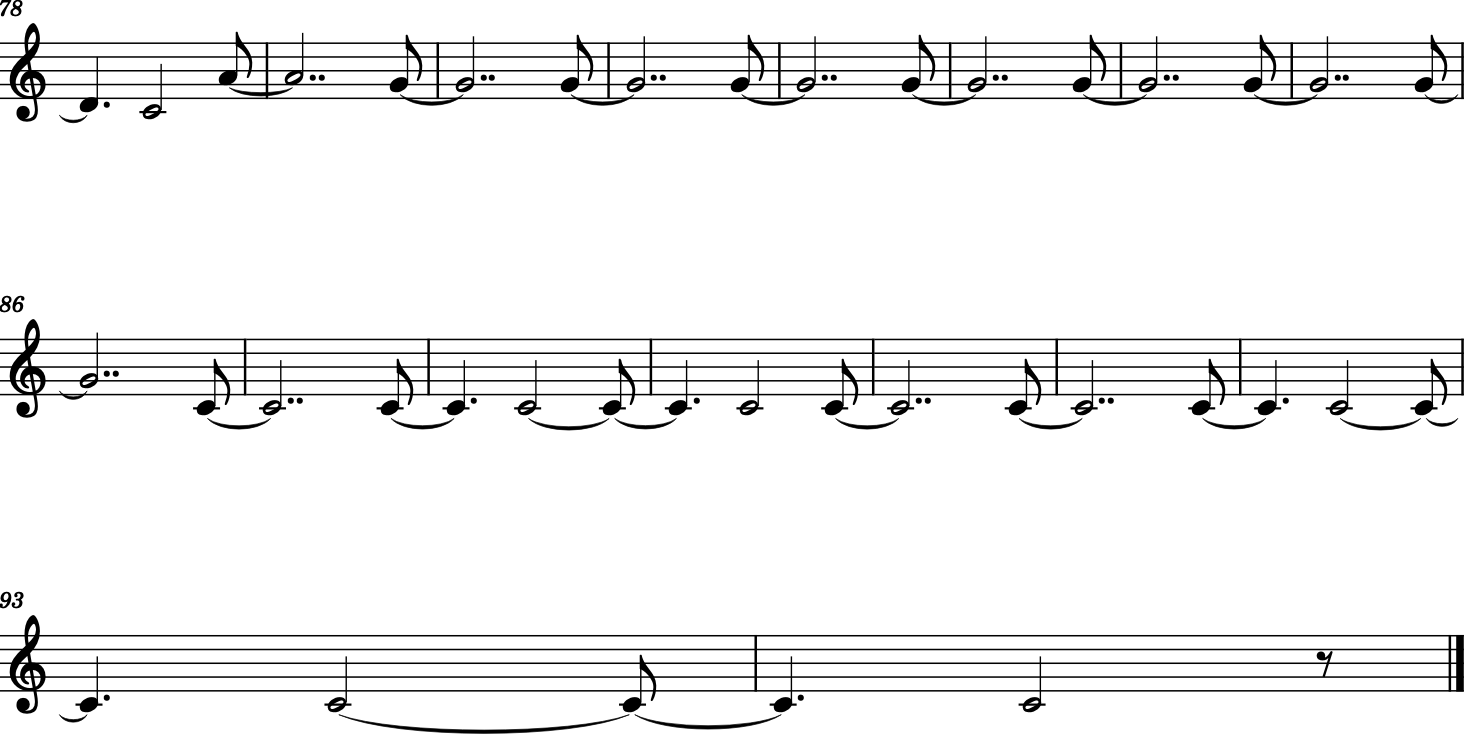

In [23]:
from datetime import datetime

melody = ga.best_individual
date = datetime.now().strftime("%d-%m-%y, %H.%M")
midi_file = melody_to_midi(melody, filename=f"viEVOLVEdi_{date}.mid")
score = converter.parse(midi_file)
score.show()

In [24]:
fitness.plot(melody)